# Analysis of Repeated Antibiotics

In [295]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import os
import glob
import gzip
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [296]:
current_working_dir = os.getcwd()
print(current_working_dir)

c:\Users\m84300af\OneDrive - The University of Manchester\Documents\GitHub\amr-uom-brit


In [297]:
def makeFilePath(pathFromWorkspace, fileName):
    workingdir = "/workspace/" if (os.name != "nt") else ""
    filepath = workingdir+pathFromWorkspace+fileName

    return filepath

In [298]:
# # reads all csv.gz files in the path without considering their dates
# import glob

# path = 'output/measures'
# all_files = glob.glob(path + "/*.csv.gz")

# data2019 = []

# for filename in all_files:
#     df = pd.read_csv(filename, index_col=None, header=0)
#     data2019.append(df)

# data = pd.concat(data2019, axis=0, ignore_index=True)

# data#.head()

In [299]:
data2019_month = {}
data2020_month = {}
data2021_month = {}
data2019 = []
data2020 = []
data2021 = []
for  i in range(1, 13):
    # data of 2019
    input_file_path = makeFilePath("output/measures/", "input_2019-"+str(i).zfill(2)+"-01.csv.gz")
    data2019_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
    data2019.append(data2019_month["%s" %i])
    # data of 2020
    input_file_path = makeFilePath("output/measures/", "input_2020-"+str(i).zfill(2)+"-01.csv.gz")
    data2020_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
    data2020.append(data2020_month["%s" %i])
    # data of 2021
    input_file_path = makeFilePath("output/measures/", "input_2021-"+str(i).zfill(2)+"-01.csv.gz")
    data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
    data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
    data2021.append(data2021_month["%s" %i])
    
data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

data = data2019.append([data2020, data2021], ignore_index=True)

In [300]:
# data2019_month = {}
# data2020_month = {}
# data2021_month = {}
# data2019 = []
# data2020 = []
# data2021 = []
# for  i in range(1, 13):
#     # data of 2019
#     data2019_month["%s" %i] = pd.read_csv("output/measures/input_2019-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
#     data2019.append(data2019_month["%s" %i])
#     # data of 2020
#     data2020_month["%s" %i] = pd.read_csv("output/measures/input_2020-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
#     data2020.append(data2020_month["%s" %i])
#     # data of 2021
#     data2021_month["%s" %i] = pd.read_csv("output/measures/input_2021-"+str(i).zfill(2)+"-01.csv.gz", compression='gzip')
#     data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
#     data2021.append(data2021_month["%s" %i])
    
# data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
# data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
# data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# data = data2019.append([data2020, data2021], ignore_index=True)

In [301]:
data#.head()

,bmi_date_measured,smoking_status_date,most_recent_unclear_smoking_cat_date,flu_vaccine_med,flu_vaccine_clinical,sgss_positive,covrx1_dat,covrx2_dat,died_date,uti_date_1,...,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id,date
0,NaN,NaN,NaN,NaN,2018-09,NaN,NaN,NaN,NaN,NaN,...,0,0,0,5,0,0,4,0,1966,2019-01-01
1,2013-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,4,0,0,0,0,7317,2019-01-01
2,2021-10,NaN,2019-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,0,0,4,5,5,3418,2019-01-01
3,2021-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5,0,0,5,0,5,0,0,4538,2019-01-01
4,2017-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-10,NaN,...,0,3,0,5,0,5,0,0,379,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,2015-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,4,0,0,0,0,0,0,3689,2021-12-01
35996,2010-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,4,0,0,4,0,0,0,428,2021-12-01
35997,2012-11,NaN,NaN,NaN,2018-08,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,5,0,0,0,121,2021-12-01
35998,2017-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,5,0,0,9180,2021-12-01


In [302]:
# def read_csv_files(year):
#     data_month+str(year) = {}
#     data+str(year) = []
#     for i in range(1, 13):
#         # data of 2019
# #        data_month+str(year) = {}
#         if i <10:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-0"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-0"+str(i)+"-01"
#         else:
#             data_month+str(year)["%s" %i] = pd.read_csv("output/measures/input_"+str(year)+"-"+str(i)+"-01.csv.gz", compression='gzip')
#             data_month+str(year)["%s" %i]['date'] = str(year)+"-"+str(i)+"-01"
#             data+str(year).append(data_month+str(year)["%s" %i])
        
#     data+str(year) = pd.concat(data_month+str(year), axis=0, ignore_index=True)

# #data = data2019.append([data2020, data2021], ignore_index=True)

In [303]:
# data2019_month = {}
# data2020_month = {}
# data2021_month = {}
# data2019 = []
# data2020 = []
# data2021 = []
# for  i in range(1, 13):
#     # data of 2019
#     input_file_path = makeFilePath("output/measures/", "input_2019-"+str(i).zfill(2)+"-01.csv.gz")
#     data2019_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2019_month["%s" %i]['date'] = "2019-"+str(i).zfill(2)+"-01"
#     data2019.append(data2019_month["%s" %i])
#     # data of 2020
#     input_file_path = makeFilePath("output/measures/", "input_2020-"+str(i).zfill(2)+"-01.csv.gz")
#     data2020_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2020_month["%s" %i]['date'] = "2020-"+str(i).zfill(2)+"-01"
#     data2020.append(data2020_month["%s" %i])
#     # data of 2021
#     input_file_path = makeFilePath("output/measures/", "input_2021-"+str(i).zfill(2)+"-01.csv.gz")
#     data2021_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#     data2021_month["%s" %i]['date'] = "2021-"+str(i).zfill(2)+"-01"
#     data2021.append(data2021_month["%s" %i])
    
# data2019 = pd.concat(data2019_month, axis=0, ignore_index=True)
# data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
# data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# data = data2019.append([data2020, data2021], ignore_index=True)

In [304]:
# def read_csv_files(year):
#     #datamonth[year] = {}
#     # data2020_month = {}
#     # data2021_month = {}
#     #data[year] = []
#     # data2020 = []
#     # data2021 = []
#     data_month ={}
#     data=[]
#     for  i in range(1, 13):
#         input_file_path = makeFilePath("output/measures/", "input_"+str(year)+"-"+str(i).zfill(2)+"-01.csv.gz")
#         data_month["%s" %i] = pd.read_csv(input_file_path, compression='gzip')
#         data_month["%s" %i]['date'] = str(year)+"-"+str(i).zfill(2)+"-01"
#         data.append(data_month["%s" %i])
#     data = pd.concat(data_month["%s" %i], axis=0, ignore_index=True)
#     # data2020 = pd.concat(data2020_month, axis=0, ignore_index=True)
#     # data2021 = pd.concat(data2021_month, axis=0, ignore_index=True)

# #data = data2019.append([data2020, data2021], ignore_index=True)

In [305]:
# read_csv_files(2019)

In [306]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covrx1_dat', 'covrx2_dat',
       'died_date', 'uti_date_1', 'uti_ab_date_1', 'uti_date_2',
       'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3', 'uti_date_4',
       'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1', 'lrti_date_2',
       'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3', 'lrti_date_4',
       'lrti_ab_date_4', 'age', 'age_cat', 'sex', 'practice', 'region', 'msoa',
       'imd', 'bmi', 'ethnicity', 'smoking_status', 'gp_count',
       'flu_vaccine_tpp', 'flu_vaccine', 'antibacterial_prescriptions',
       'antibacterial_brit', 'broad_spectrum_antibiotics_prescriptions',
       'primary_care_covid', 'admitted', 'uti_counts', 'lrti_counts',
       'urti_counts', 'sinusitis_counts', 'ot_externa_counts',
       'otmedia_counts', 'uti_pt', 'lrti_pt', 'urti_pt', 'sinusitis_pt',
       'ot_externa_pt', 'otmedia_

In [307]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 65 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   bmi_date_measured                         28836 non-null  object 
 1   smoking_status_date                       3600 non-null   object 
 2   most_recent_unclear_smoking_cat_date      3600 non-null   object 
 3   flu_vaccine_med                           3600 non-null   object 
 4   flu_vaccine_clinical                      3600 non-null   object 
 5   sgss_positive                             3600 non-null   object 
 6   covrx1_dat                                0 non-null      float64
 7   covrx2_dat                                0 non-null      float64
 8   died_date                                 3600 non-null   object 
 9   uti_date_1                                3600 non-null   object 
 10  uti_ab_date_1                     

In [308]:
data.describe()

,covrx1_dat,covrx2_dat,age,practice,imd,bmi,ethnicity,gp_count,flu_vaccine_tpp,flu_vaccine,...,otmedia_pt,uti_ab_count_1,uti_ab_count_2,uti_ab_count_3,uti_ab_count_4,lrti_ab_count_1,lrti_ab_count_2,lrti_ab_count_3,lrti_ab_count_4,patient_id
count,0.0,0.0,36000.000000,36000.000000,36000.000000,36000.000000,27000.000000,36000.000000,36000.000000,36000.000000,...,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,NaN,NaN,40.208778,24.480167,2.864444,22.435838,1.590000,3.311139,0.100000,0.100000,...,0.200000,0.899222,0.895417,0.902389,0.902111,0.898389,0.899028,0.896444,0.902194,5018.056000
std,NaN,NaN,23.721695,4.982571,1.524146,13.289348,1.275277,3.560800,0.300004,0.300004,...,0.400006,1.857327,1.849840,1.864303,1.864169,1.855261,1.857667,1.850926,1.863063,2889.025232
min,NaN,NaN,0.000000,4.000000,0.000000,-4.259669,1.000000,-9.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,21.000000,21.000000,2.000000,15.793426,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2511.000000
50%,NaN,NaN,40.000000,24.000000,3.000000,25.510309,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5050.000000
75%,NaN,NaN,59.000000,28.000000,4.000000,31.902258,1.000000,6.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7518.250000
max,NaN,NaN,109.000000,45.000000,5.000000,60.497724,5.000000,18.000000,1.000000,1.000000,...,1.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,9999.000000


In [309]:
data.uti_date_1.value_counts()

2020-05-30    11
2019-10-24    10
2020-07-05     9
2020-07-04     8
2019-03-17     8
              ..
2021-03-04     1
2020-01-01     1
2020-12-12     1
2021-01-13     1
2019-02-20     1
Name: uti_date_1, Length: 1061, dtype: int64

In [310]:
data.loc[:, ['lrti_date_1', 'lrti_ab_count_1', 'lrti_date_2', 'lrti_ab_count_2', 'lrti_date_3', 'lrti_ab_count_3', 'lrti_date_4', 'lrti_ab_count_4']]

,lrti_date_1,lrti_ab_count_1,lrti_date_2,lrti_ab_count_2,lrti_date_3,lrti_ab_count_3,lrti_date_4,lrti_ab_count_4
0,NaN,0,NaN,0,2020-05-12,4,NaN,0
1,NaN,0,NaN,0,NaN,0,NaN,0
2,NaN,0,NaN,4,NaN,5,NaN,5
3,NaN,0,NaN,5,NaN,0,NaN,0
4,NaN,0,NaN,5,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
35995,NaN,0,NaN,0,NaN,0,NaN,0
35996,NaN,4,NaN,0,NaN,0,NaN,0
35997,NaN,5,NaN,0,NaN,0,NaN,0
35998,NaN,0,NaN,5,NaN,0,2020-10-05,0


In [311]:
#data.loc[:, ['urti_date_1', 'urti_ab_count_1', 'urti_date_2', 'urti_ab_count_2', 'urti_date_3', 'urti_ab_count_3', 'urti_date_4', 'urti_ab_count_4']]

In [312]:
data.loc[:, ['uti_date_1', 'uti_ab_count_1', 'uti_date_2', 'uti_ab_count_2', 'uti_date_3', 'uti_ab_count_3', 'uti_date_4', 'uti_ab_count_4']]

,uti_date_1,uti_ab_count_1,uti_date_2,uti_ab_count_2,uti_date_3,uti_ab_count_3,uti_date_4,uti_ab_count_4
0,NaN,0,NaN,0,NaN,0,NaN,5
1,NaN,0,NaN,0,NaN,0,NaN,4
2,NaN,4,NaN,0,NaN,0,NaN,0
3,NaN,5,NaN,0,NaN,0,2020-03-03,5
4,NaN,0,NaN,3,NaN,0,NaN,5
...,...,...,...,...,...,...,...,...
35995,NaN,0,NaN,4,NaN,0,NaN,0
35996,NaN,0,NaN,4,2020-12-29,0,NaN,0
35997,NaN,0,NaN,0,NaN,0,2019-11-18,0
35998,NaN,0,NaN,0,NaN,0,NaN,0


In [313]:
# data['repeated_ABs_UTI'] = np.nan

# col0 = data.columns.get_loc('repeated_ABs_UTI')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# for idx, x in enumerate(data['repeated_ABs_UTI']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             n=n+1
#     data.iat[idx, col0]=n

In [314]:
data['uti_date_1'] = pd.to_datetime(data['uti_date_1'], format='%Y-%m-%d', errors='ignore')
data['uti_date_2'] = pd.to_datetime(data['uti_date_2'], format='%Y-%m-%d', errors='ignore')
data['uti_date_3'] = pd.to_datetime(data['uti_date_3'], format='%Y-%m-%d', errors='ignore')
data['uti_date_4'] = pd.to_datetime(data['uti_date_4'], format='%Y-%m-%d', errors='ignore')

In [315]:
data['lrti_date_1'] = pd.to_datetime(data['lrti_date_1'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_2'] = pd.to_datetime(data['lrti_date_2'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_3'] = pd.to_datetime(data['lrti_date_3'], format='%Y-%m-%d', errors='ignore')
data['lrti_date_4'] = pd.to_datetime(data['lrti_date_4'], format='%Y-%m-%d', errors='ignore')

In [316]:
# data['uti_ab_date_1'] = pd.to_datetime(data['uti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_2'] = pd.to_datetime(data['uti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_3'] = pd.to_datetime(data['uti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['uti_ab_date_4'] = pd.to_datetime(data['uti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

# data['lrti_ab_date_1'] = pd.to_datetime(data['lrti_ab_date_1'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_2'] = pd.to_datetime(data['lrti_ab_date_2'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_3'] = pd.to_datetime(data['lrti_ab_date_3'], format='%Y-%m-%d', errors='ignore')
# data['lrti_ab_date_4'] = pd.to_datetime(data['lrti_ab_date_4'], format='%Y-%m-%d', errors='ignore')

In [317]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1

#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [318]:
# data['repeated_ABs'] = np.nan
# col0 = data.columns.get_loc('repeated_ABs')

# col1 = data.columns.get_loc('uti_ab_count_1')
# col2 = data.columns.get_loc('uti_ab_count_2')
# col3 = data.columns.get_loc('uti_ab_count_3')
# col4 = data.columns.get_loc('uti_ab_count_4')

# col5 = data.columns.get_loc('uti_date_1')
# col6 = data.columns.get_loc('uti_date_2')
# col7 = data.columns.get_loc('uti_date_3')
# col8 = data.columns.get_loc('uti_date_4')

# col9 = data.columns.get_loc('lrti_ab_count_1')
# col10 = data.columns.get_loc('lrti_ab_count_2')
# col11 = data.columns.get_loc('lrti_ab_count_3')
# col12 = data.columns.get_loc('lrti_ab_count_4')

# col13 = data.columns.get_loc('lrti_date_1')
# col14 = data.columns.get_loc('lrti_date_2')
# col15 = data.columns.get_loc('lrti_date_3')
# col16 = data.columns.get_loc('lrti_date_4')

# for idx, x in enumerate(data['repeated_ABs']):
#     n=0
#     if data.iat[idx, col2] > 0:
#         if data.iat[idx, col1] > 0:
#             if (data.iat[idx,col6]-data.iat[idx,col5]).days > 30:
#                 n=n+1
#     if data.iat[idx, col3] > 0:
#         if data.iat[idx, col2] > 0:
#             if (data.iat[idx,col7]-data.iat[idx,col6]).days > 30:
#                 n=n+1
#     if data.iat[idx, col4] > 0:
#         if data.iat[idx, col3] > 0:
#             if (data.iat[idx,col8]-data.iat[idx,col7]).days > 30:
#                 n=n+1

#     if data.iat[idx, col1] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col5]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col10] > 0:
#         if data.iat[idx, col9] > 0:
#             if (data.iat[idx,col14]-data.iat[idx,col13]).days > 30:
#                 n=n+1
#     if data.iat[idx, col11] > 0:
#         if data.iat[idx, col10] > 0:
#             if (data.iat[idx,col15]-data.iat[idx,col14]).days > 30:
#                 n=n+1
#     if data.iat[idx, col12] > 0:
#         if data.iat[idx, col11] > 0:
#             if (data.iat[idx,col16]-data.iat[idx,col15]).days > 30:
#                 n=n+1
    
#     data.iat[idx, col0]=n

In [319]:
# data['repeated_ABs'].value_counts()

## Cox model

In [320]:
import math
from lifelines import CoxPHFitter
from lifelines.calibration import survival_probability_calibration

In [339]:
data['repeated_ABs'] = np.nan
col0 = data.columns.get_loc('repeated_ABs')

col1 = data.columns.get_loc('uti_ab_count_1')
col2 = data.columns.get_loc('uti_ab_count_2')
col3 = data.columns.get_loc('uti_ab_count_3')
col4 = data.columns.get_loc('uti_ab_count_4')

col5 = data.columns.get_loc('uti_date_1')
col6 = data.columns.get_loc('uti_date_2')
col7 = data.columns.get_loc('uti_date_3')
col8 = data.columns.get_loc('uti_date_4')

col9 = data.columns.get_loc('lrti_ab_count_1')
col10 = data.columns.get_loc('lrti_ab_count_2')
col11 = data.columns.get_loc('lrti_ab_count_3')
col12 = data.columns.get_loc('lrti_ab_count_4')

col13 = data.columns.get_loc('lrti_date_1')
col14 = data.columns.get_loc('lrti_date_2')
col15 = data.columns.get_loc('lrti_date_3')
col16 = data.columns.get_loc('lrti_date_4')

for idx, x in enumerate(data['repeated_ABs']):
    n=0
    if data.iat[idx, col2] > 0:
        if data.iat[idx, col1] > 0:
            if (data.iat[idx,col6]-data.iat[idx,col5]).days < 190:
                n=(data.iat[idx,col6]-data.iat[idx,col5]).days
    if data.iat[idx, col3] > 0:
        if data.iat[idx, col2] > 0:
            if (data.iat[idx,col7]-data.iat[idx,col6]).days < 190:
                n=(data.iat[idx,col7]-data.iat[idx,col6]).days
    if data.iat[idx, col4] > 0:
        if data.iat[idx, col3] > 0:
            if (data.iat[idx,col8]-data.iat[idx,col7]).days < 190:
                n=(data.iat[idx,col8]-data.iat[idx,col7]).days

    if data.iat[idx, col1] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col5]-data.iat[idx,col13]).days < 190:
                n=(data.iat[idx,col5]-data.iat[idx,col13]).days
    if data.iat[idx, col10] > 0:
        if data.iat[idx, col9] > 0:
            if (data.iat[idx,col14]-data.iat[idx,col13]).days < 190:
                n=(data.iat[idx,col14]-data.iat[idx,col13]).days
    if data.iat[idx, col11] > 0:
        if data.iat[idx, col10] > 0:
            if (data.iat[idx,col15]-data.iat[idx,col14]).days < 190:
                n=(data.iat[idx,col15]-data.iat[idx,col14]).days
    if data.iat[idx, col12] > 0:
        if data.iat[idx, col11] > 0:
            if (data.iat[idx,col16]-data.iat[idx,col15]).days < 190:
                n=(data.iat[idx,col16]-data.iat[idx,col15]).days
    
    data.iat[idx, col0]=n

data['repeated_ABs'].value_counts()

 0.0      35941
 141.0        2
 137.0        2
-508.0        2
-423.0        1
 120.0        1
 21.0         1
 133.0        1
 165.0        1
 180.0        1
-54.0         1
-66.0         1
 147.0        1
-654.0        1
-430.0        1
 109.0        1
-205.0        1
-398.0        1
-15.0         1
-23.0         1
-950.0        1
-638.0        1
-127.0        1
-124.0        1
-362.0        1
-509.0        1
-429.0        1
 154.0        1
-93.0         1
-876.0        1
-320.0        1
-448.0        1
-248.0        1
 182.0        1
-623.0        1
-982.0        1
-115.0        1
-201.0        1
-602.0        1
-405.0        1
-24.0         1
 54.0         1
-108.0        1
-919.0        1
-828.0        1
 48.0         1
-174.0        1
-324.0        1
-624.0        1
-490.0        1
-855.0        1
-311.0        1
 46.0         1
-607.0        1
-119.0        1
 102.0        1
-170.0        1
Name: repeated_ABs, dtype: int64

In [340]:
# replace any values smaller than -90
a = np.array(data['repeated_ABs'].values.tolist())
data['repeated_ABs'] = np.where(a < -190, np.nan, a).tolist()

# calculate absolute values for all rows in repeated_ABs column
data['repeated_ABs_time'] = data['repeated_ABs'].abs()

data['repeated_ABs_time'].value_counts()

0.0      35941
141.0        2
137.0        2
54.0         2
133.0        1
93.0         1
154.0        1
124.0        1
127.0        1
23.0         1
109.0        1
147.0        1
66.0         1
180.0        1
165.0        1
120.0        1
21.0         1
182.0        1
15.0         1
102.0        1
119.0        1
46.0         1
174.0        1
48.0         1
108.0        1
24.0         1
115.0        1
170.0        1
Name: repeated_ABs_time, dtype: int64

In [341]:
data['repeated_ABs_binary'] = data['repeated_ABs_time'].mask(data['repeated_ABs_time'] > 0, 1)

data['repeated_ABs_binary'].value_counts()

0.0    35941
1.0       30
Name: repeated_ABs_binary, dtype: int64

In [342]:
data.columns

Index(['bmi_date_measured', 'smoking_status_date',
       'most_recent_unclear_smoking_cat_date', 'flu_vaccine_med',
       'flu_vaccine_clinical', 'sgss_positive', 'covrx1_dat', 'covrx2_dat',
       'died_date', 'uti_date_1', 'uti_ab_date_1', 'uti_date_2',
       'uti_ab_date_2', 'uti_date_3', 'uti_ab_date_3', 'uti_date_4',
       'uti_ab_date_4', 'lrti_date_1', 'lrti_ab_date_1', 'lrti_date_2',
       'lrti_ab_date_2', 'lrti_date_3', 'lrti_ab_date_3', 'lrti_date_4',
       'lrti_ab_date_4', 'age', 'age_cat', 'sex', 'practice', 'region', 'msoa',
       'imd', 'bmi', 'ethnicity', 'smoking_status', 'gp_count',
       'flu_vaccine_tpp', 'flu_vaccine', 'antibacterial_prescriptions',
       'antibacterial_brit', 'broad_spectrum_antibiotics_prescriptions',
       'primary_care_covid', 'admitted', 'uti_counts', 'lrti_counts',
       'urti_counts', 'sinusitis_counts', 'ot_externa_counts',
       'otmedia_counts', 'uti_pt', 'lrti_pt', 'urti_pt', 'sinusitis_pt',
       'ot_externa_pt', 'otmedia_

In [343]:
cph = CoxPHFitter()
Cox_data = data[['repeated_ABs_time', 'repeated_ABs_binary', 'age', 'sex', 'bmi', 'flu_vaccine', 'gp_count', 'antibacterial_prescriptions']]

# printing number of missing values in each variable 
Cox_data.isnull().sum()

repeated_ABs_time              29
repeated_ABs_binary            29
age                             0
sex                             0
bmi                             0
flu_vaccine                     0
gp_count                        0
antibacterial_prescriptions     0
dtype: int64

In [344]:
Cox_data = Cox_data.dropna(axis='rows')
Cox_data.isnull().sum()

repeated_ABs_time              0
repeated_ABs_binary            0
age                            0
sex                            0
bmi                            0
flu_vaccine                    0
gp_count                       0
antibacterial_prescriptions    0
dtype: int64

In [345]:
print(Cox_data.shape)

(35971, 8)


In [346]:
# cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex + bmi + flu_vaccine + gp_count + antibacterial_prescriptions")
# cph.print_summary()

In [347]:
cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="sex + flu_vaccine")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 35971 total observations, 35941 right-censored observations>
             duration col = 'repeated_ABs_time'
                event col = 'repeated_ABs_binary'
      baseline estimation = breslow
   number of observations = 35971
number of events observed = 30
   partial log-likelihood = -72.74
         time fit was run = 2022-01-12 12:51:58 UTC

---
              coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                           
flu_vaccine  -1.61       0.20       1.05            -3.66             0.44                 0.03                 1.55
sex[T.M]     -0.12       0.89       0.39            -0.88             0.63                 0.42                 1.89

                z    p   -log2(p)
covariate                        
flu_vaccine -1.54 0.12       3.02
sex[T.M]    -0.31 0.75       0.41
---
Concordance = 0.56
Partial AIC = 149.49
log-likelihood ratio test = 3.83 on 2 df
-log2(p) of ll-ratio test = 2.76

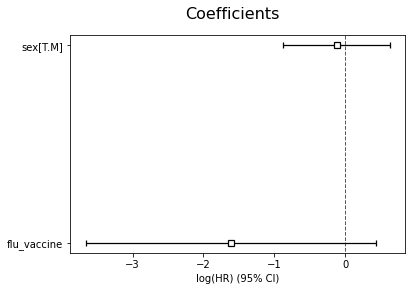

In [348]:
cph.plot()
plt.suptitle('Coefficients', fontsize=16)
plt.savefig('../output/hospitalisation_risk/coefficients.jpg')
plt.show()

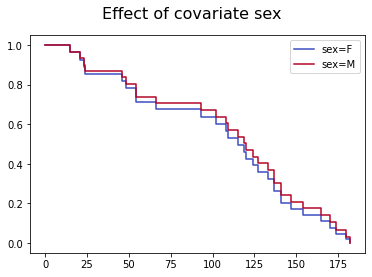

In [349]:
cph.plot_partial_effects_on_outcome(covariates='sex', 
                                    values=['F', 'M'], 
                                    cmap='coolwarm',
                                    plot_baseline=False)
plt.suptitle('Effect of covariate sex', fontsize=16)
plt.savefig('../output/hospitalisation_risk/repeatedABs_effect_covariate_sex.jpg')
plt.show()

In [350]:
Cox_data['flu_vaccine'] = Cox_data['flu_vaccine'].astype("category")
# Cox_data['age'] = Cox_data['age'].astype("category")
# # Cox_data['bmi'] = Cox_data['bmi'].astype("category")
# Cox_data['gp_count'] = Cox_data['gp_count'].astype("category")
# Cox_data['antibacterial_prescriptions'] = Cox_data['antibacterial_prescriptions'].astype("category")

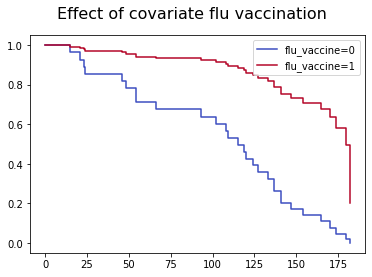

In [352]:
cph.plot_partial_effects_on_outcome(covariates='flu_vaccine', 
                                    values=[0, 1], 
                                    cmap='coolwarm',
                                    plot_baseline=False)
plt.suptitle('Effect of covariate flu vaccination', fontsize=16)
plt.savefig('../output/hospitalisation_risk/repeatedABs_effect_covariate_flu_vaccine.jpg')
plt.show()

In [48]:
# from lifelines.calibration import survival_probability_calibration

# cph.fit(Cox_data, duration_col='repeated_ABs_time', event_col='repeated_ABs_binary', formula="age + sex")

# #plt.figure()

# survival_probability_calibration(cph, Cox_data, t0=90)
# #survival_probability_calibration(cph, dataCox, t0=70)

## Questions:
- I expect all dates to be within the one month period that the input data is supposedly generated/collected. How it is justified to have a date of 2020 (e.g. UTI diagnosis), while the data belongs to 2019? Is it becuase of having dummy data?
- Is our focus on repeated ABs for just one specific infection or any repeated ABs for any infection (LRTI and UTI)?